In [35]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
# Load the data from the CSV file
df = pd.read_csv('merged_pokemon_data.csv')

In [37]:
# Convert the 'Month' column to datetime (make sure the format matches your data)
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')

# Make sure 'Average' is numeric
df['Average'] = pd.to_numeric(df['Average'], errors='coerce')

In [5]:
# Rarity Order for sorting
# Higher value means rarer card
rarityOrder = {
    "Common": 10,
    "Uncommon": 20,
    "Rare": 30,                         # Regular
    "Classic Collection": 31,
    "Rare Holo": 40,                    # Holofoil
    "Double Rare": 50,                  # EX
    "Ultra Rare": 60,                   # Unique card classification
    "Rare Ultra": 60,                   # Unique card classification
    "Rare Holo Star": 61,
    "Rare Prime": 61,
    "Rare Holo LV.X": 61,
    "Rare Holo EX": 61,
    "Rare Holo GX": 61,
    "LEGEND": 61,
    "Rare BREAK": 61,
    "Amazing Rare": 61,
    "Rare Prism Star": 61,
    "Rare ACE": 61,
    "ACE SPEC Rare": 61,
    "Radiant Rare": 62,
    "Rare Holo V": 63,
    "Rare Holo VSTAR": 64,
    "Rare Holo VMAX": 65,
    "Trainer Gallery Rare Holo": 66,
    "Rare Secret": 70,                  # Out of numbers
    "Rare Shining": 71,                 # Shiny Pokemon
    "Shiny Rare": 72,                   # Shiny Pokemon
    "Rare Shiny": 72,                   # Shiny Pokemon
    "Rare Shiny GX": 73,                # Shiny Pokemon
    "Shiny Ultra Rare": 73,             # Shiny Pokemon
    "Rare Rainbow": 74,
    "Illustration Rare": 75,            # Full-Art
    "Special Illustration Rare": 76,    # Full-Art
    "Hyper Rare": 80,                   # Gold Cards
    "Promo": 90                         # Event Cards
}

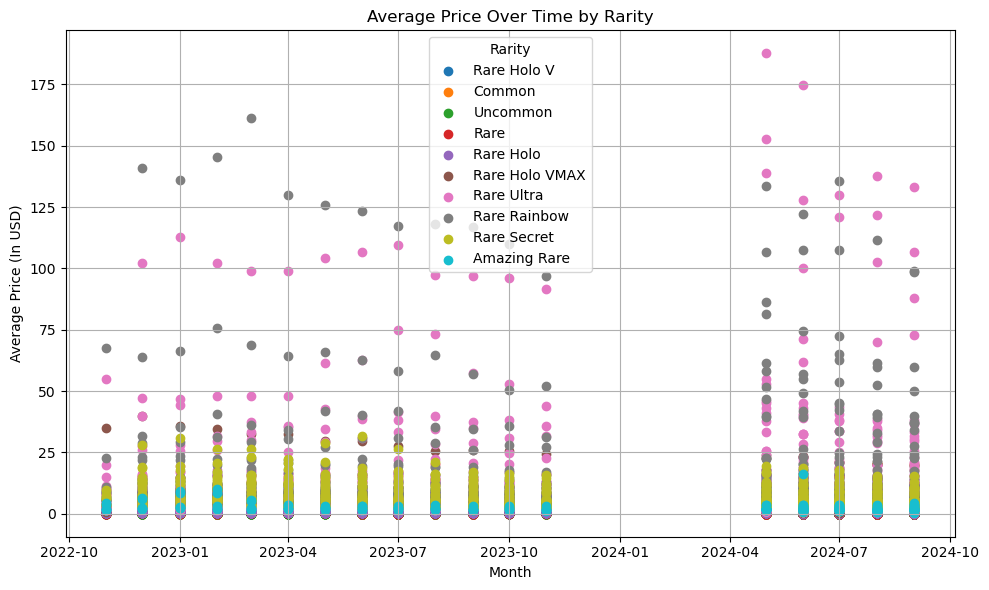

In [38]:
# Plotting: Scatter Plot
plt.figure(figsize=(10, 6))

# Loop over each unique Rarity and plot the Average over Time as scatter points
dfs_by_rarity = []
for rarity in df['Rarity'].unique():
    subset = df[df['Rarity'] == rarity]
    dfs_by_rarity.append(subset)
    plt.scatter(subset['Month'], subset['Average'].div(100).round(2), label=rarity, marker='o')

# Set graph title and labels
plt.title('Average Price Over Time by Rarity')
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.legend(title='Rarity')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


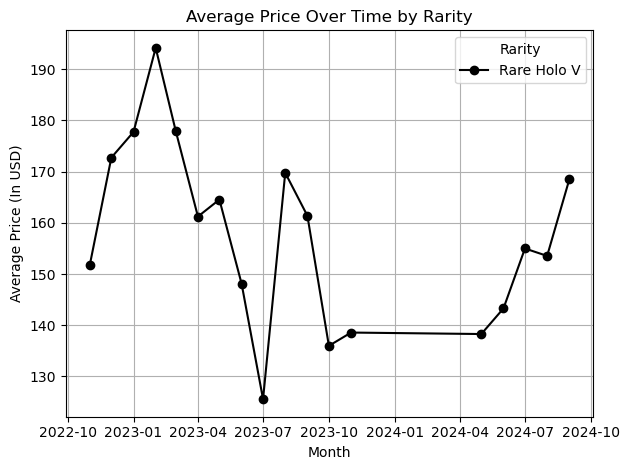

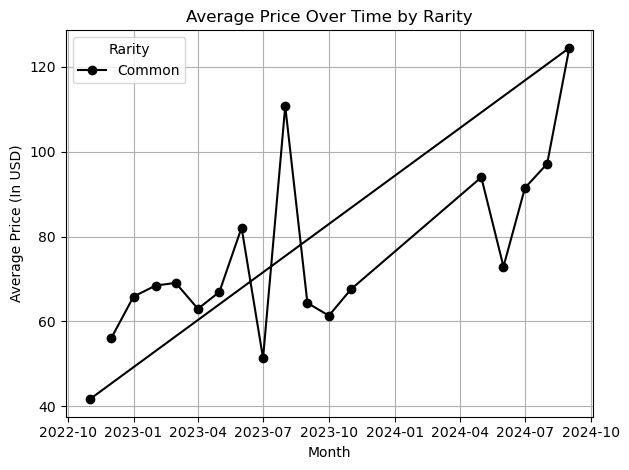

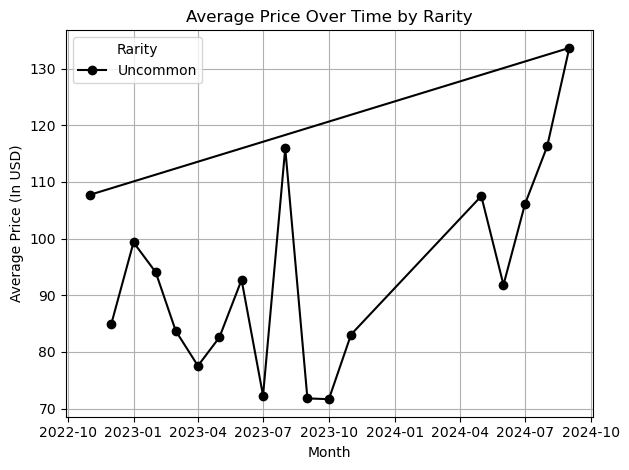

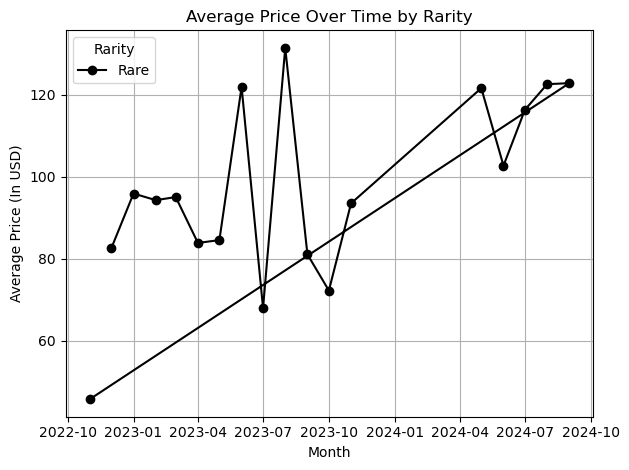

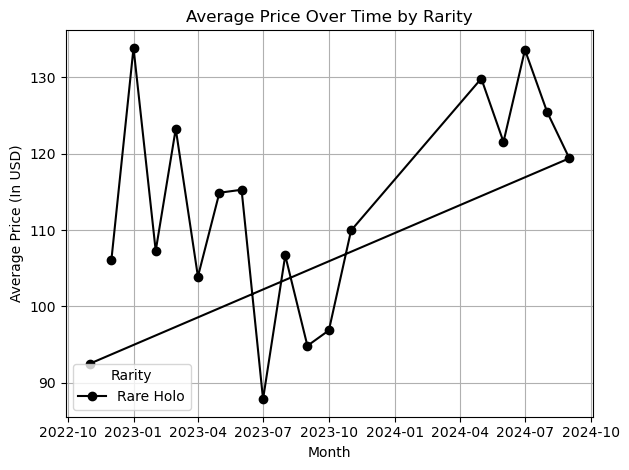

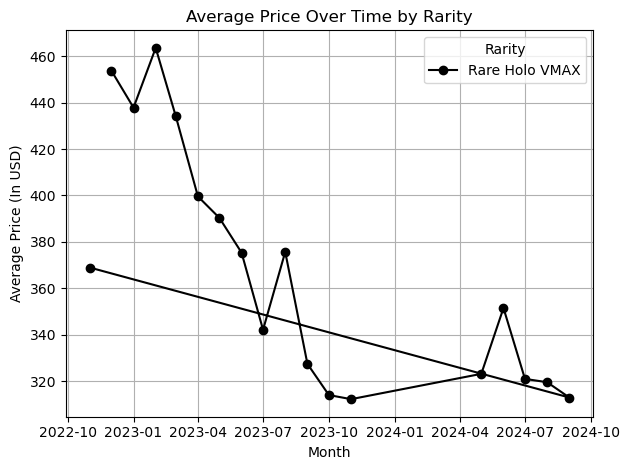

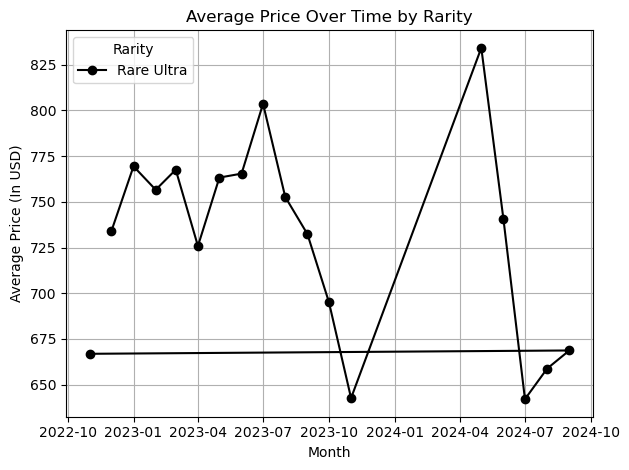

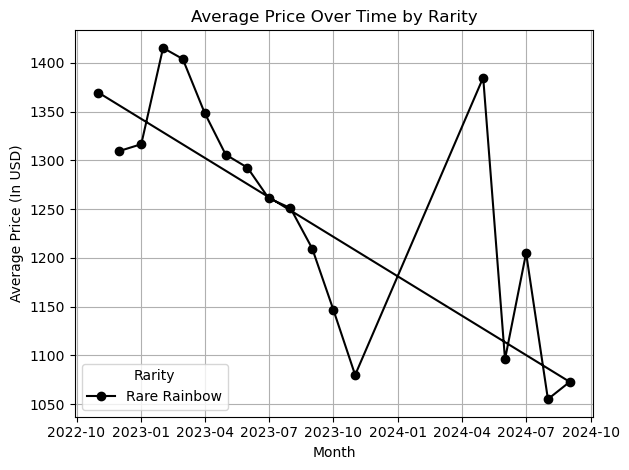

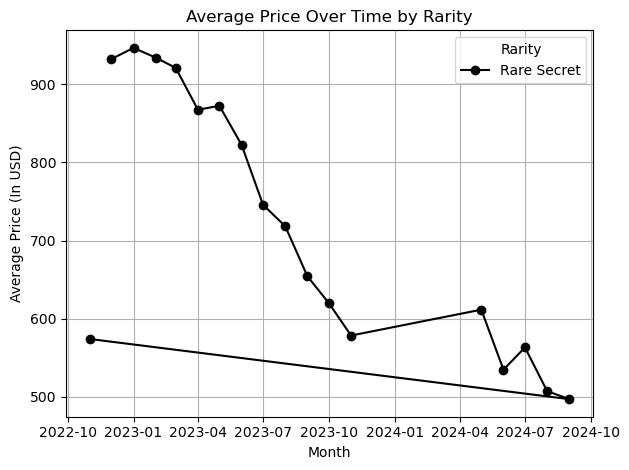

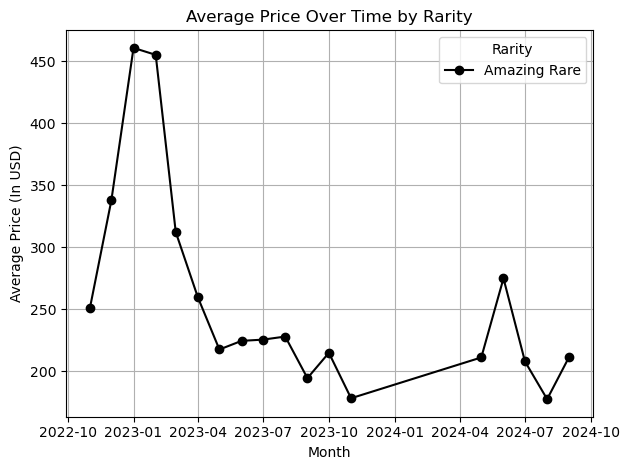

In [54]:
for rarity_df in dfs_by_rarity:
    # print(rarity_df.columns)
    # Find list of months
    months = rarity_df['Month'].unique()

    # Iterate over df by month finding the average
    avg_by_month = []
    for month in months:
        month_df = rarity_df[rarity_df['Month'] == month]
        avg_by_month.append(month_df['Average'].mean())

    rarity = rarity_df.iloc[0]['Rarity']
    plt.figure()
    plt.plot(rarity_df['Month'].unique(), avg_by_month, label=rarity, marker='o', c='black')
    plt.title('Average Price Over Time by Rarity')
    plt.xlabel('Month')
    plt.ylabel('Average Price (In USD)')
    plt.legend(title='Rarity')
    plt.grid(True)
    plt.tight_layout()
    plt.show()